In [1]:
!pip install kaggle --quiet
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nirbhay450","key":"99c7af752eb90897f7bbf9e76d4deb27"}'}

In [2]:
!mkdir ~/.kaggle

In [3]:
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ardamavi/sign-language-digits-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sign-language-digits-dataset' dataset.
Path to dataset files: /kaggle/input/sign-language-digits-dataset


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [10]:
x= np.load("/kaggle/input/sign-language-digits-dataset/X.npy")
y= np.load("/kaggle/input/sign-language-digits-dataset/Y.npy")

In [11]:
x.shape

(2062, 64, 64)

In [12]:
y.shape

(2062, 10)

In [13]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.2)

In [14]:
model = Sequential([
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu",input_shape=(64,64,1)),

    keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(256, kernel_size=(3, 3), activation="relu"),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax",)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,749,962 (10.49 MB)

 Trainable params: 2,749,962 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer="Adam", loss="categorical_crossentropy",metrics=["accuracy"])

In [25]:
history=model.fit(train_x,train_y,epochs=10,validation_split=0.2,batch_size=1,shuffle=True)

Epoch 1/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7602 - loss: 0.7935 - val_accuracy: 0.9333 - val_loss: 0.2178
Epoch 2/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9415 - loss: 0.1701 - val_accuracy: 0.9242 - val_loss: 0.2236
Epoch 3/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9363 - loss: 0.1692 - val_accuracy: 0.9030 - val_loss: 0.3996
Epoch 4/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9648 - loss: 0.1228 - val_accuracy: 0.9273 - val_loss: 0.2578
Epoch 5/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9642 - loss: 0.1206 - val_accuracy: 0.9424 - val_loss: 0.2122
Epoch 6/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9778 - loss: 0.0716 - val_accuracy: 0.9394 - val_loss: 0.3333
Epoch 7/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9630 - loss: 0.1457 - val_accuracy: 0.9364 - val_loss: 0.3044
Epoch 8/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9685 - loss: 0.1084 

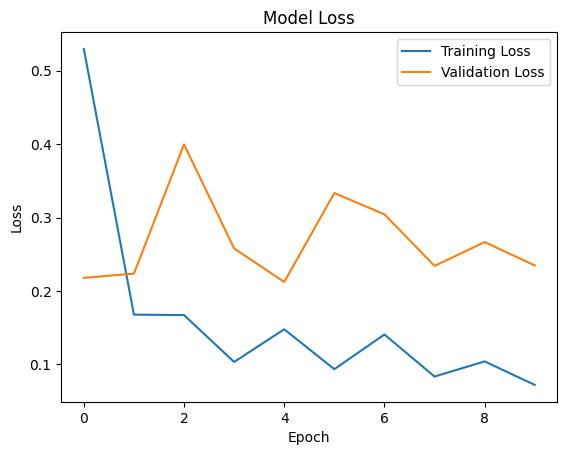

In [27]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend()
plt.show()


In [28]:

y_pred = model.predict(test_x)
y_pred_classes = np.argmax(y_pred, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc = accuracy_score(np.argmax(test_y, axis=1), y_pred_classes)
print(" Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(np.argmax(test_y, axis=1), y_pred_classes))

 Test Accuracy: 0.9394673123486683

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       1.00      0.97      0.99        37
           2       0.89      0.97      0.93        40
           3       0.93      0.93      0.93        42
           4       0.97      0.94      0.95        32
           5       0.95      0.97      0.96        38
           6       0.92      0.94      0.93        49
           7       1.00      0.91      0.95        44
           8       0.86      0.86      0.86        43
           9       0.98      1.00      0.99        46

    accuracy                           0.94       413
   macro avg       0.94      0.94      0.94       413
weighted avg       0.94      0.94      0.94       413



In [36]:
model.save('sign_language_model.h5')

In [31]:
img = x[1].reshape(1, 64, 64)
pred = model.predict(img)
print("Predicted class:", np.argmax(pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted class: 0
